<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/rna-seq/03_fastqc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FastQC: kalite raporunu okumak

Geçen defterde kaliteyi elle saydık; şimdi aynı işi alanın standart aracına yaptırıp raporunu okumayı öğreniyoruz. Ve açık duran soruyu kovalıyoruz: KO_1'in eşleşme oranı neden düşüktü?

In [1]:
import urllib.request
for d in ['SRR384977_1M.fastq.gz', 'SRR384980_1M.fastq.gz']:
    urllib.request.urlretrieve('https://zenodo.org/records/22206786/files/' + d + '?download=1', d)
    print(d, 'indi')

SRR384977_1M.fastq.gz indi
SRR384980_1M.fastq.gz indi


In [3]:
%%bash
set -e
apt-get -qq update > /dev/null
apt-get -qq install -y fastqc > /dev/null
fastqc --version

[0.035s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.035s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
FastQC v0.11.9


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 1. Raporları üretiyorum

FastQC her dosya için bir rapor üretir; içinde on küsur modül vardır ve her birine PASS, WARN ya da FAIL damgası vurur. Damgalar körü körüne okunmaz; birazdan konuşacağız.

In [4]:
%%bash
fastqc -q SRR384977_1M.fastq.gz SRR384980_1M.fastq.gz
unzip -oq SRR384977_1M_fastqc.zip
unzip -oq SRR384980_1M_fastqc.zip
echo bitti

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
bitti


## 2. Damga tabloları yan yana

In [5]:
for d in ['SRR384977_1M_fastqc', 'SRR384980_1M_fastqc']:
    print('\n===', d)
    print(open(f'{d}/summary.txt').read())


=== SRR384977_1M_fastqc
PASS	Basic Statistics	SRR384977_1M.fastq.gz
PASS	Per base sequence quality	SRR384977_1M.fastq.gz
PASS	Per tile sequence quality	SRR384977_1M.fastq.gz
PASS	Per sequence quality scores	SRR384977_1M.fastq.gz
FAIL	Per base sequence content	SRR384977_1M.fastq.gz
PASS	Per sequence GC content	SRR384977_1M.fastq.gz
FAIL	Per base N content	SRR384977_1M.fastq.gz
PASS	Sequence Length Distribution	SRR384977_1M.fastq.gz
PASS	Sequence Duplication Levels	SRR384977_1M.fastq.gz
PASS	Overrepresented sequences	SRR384977_1M.fastq.gz
FAIL	Adapter Content	SRR384977_1M.fastq.gz


=== SRR384980_1M_fastqc
PASS	Basic Statistics	SRR384980_1M.fastq.gz
PASS	Per base sequence quality	SRR384980_1M.fastq.gz
PASS	Per tile sequence quality	SRR384980_1M.fastq.gz
PASS	Per sequence quality scores	SRR384980_1M.fastq.gz
FAIL	Per base sequence content	SRR384980_1M.fastq.gz
WARN	Per sequence GC content	SRR384980_1M.fastq.gz
PASS	Per base N content	SRR384980_1M.fastq.gz
PASS	Sequence Length Distributio

## 3. İki kritik grafiğe bakıyorum

Önce konum bazında kalite: geçen defterde gördüğümüz N kuyruklarının resmi. Sonra adaptör içeriği: okuma, parçadan uzunsa cihaz adaptörü de okur; o yapay dizi eşleşmeyi bozar. Baş şüphelimiz bu.


=== SRR384977_1M_fastqc


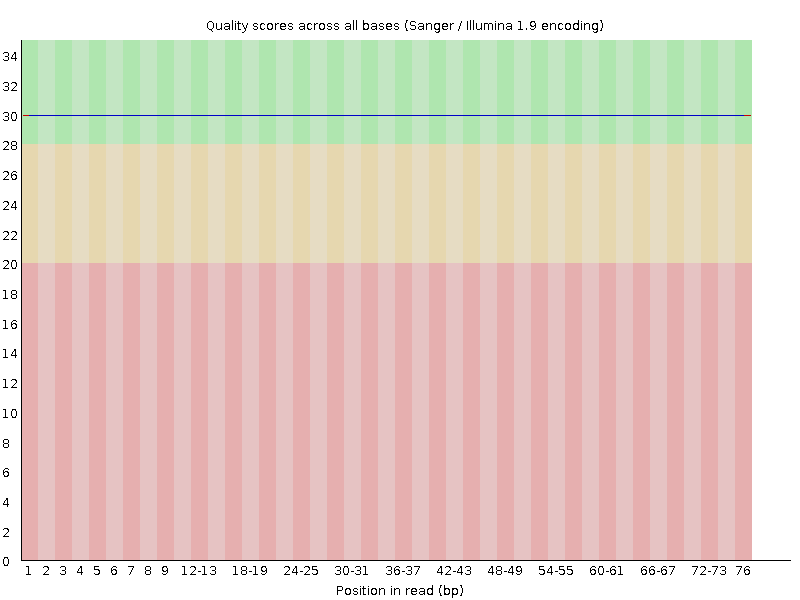

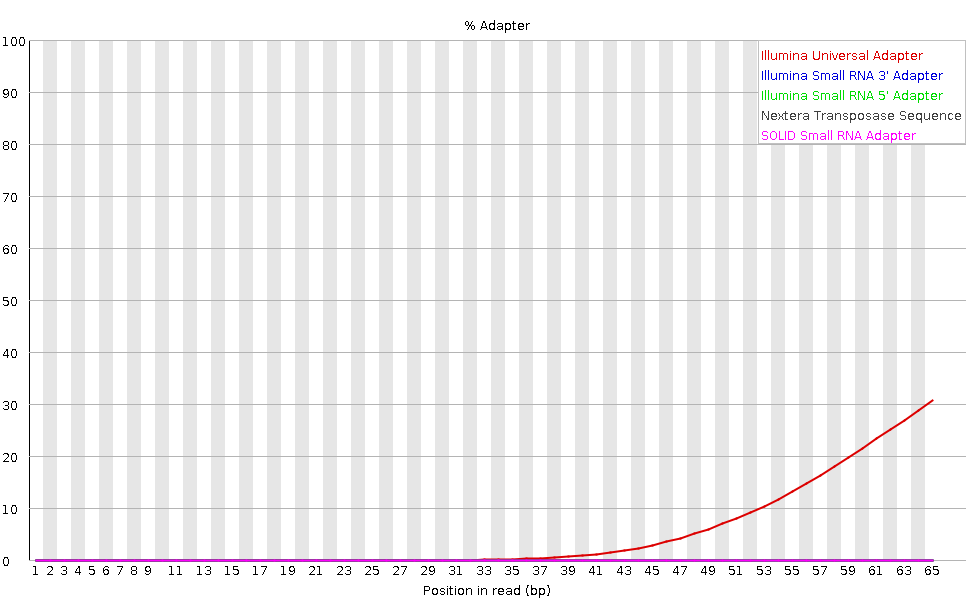


=== SRR384980_1M_fastqc


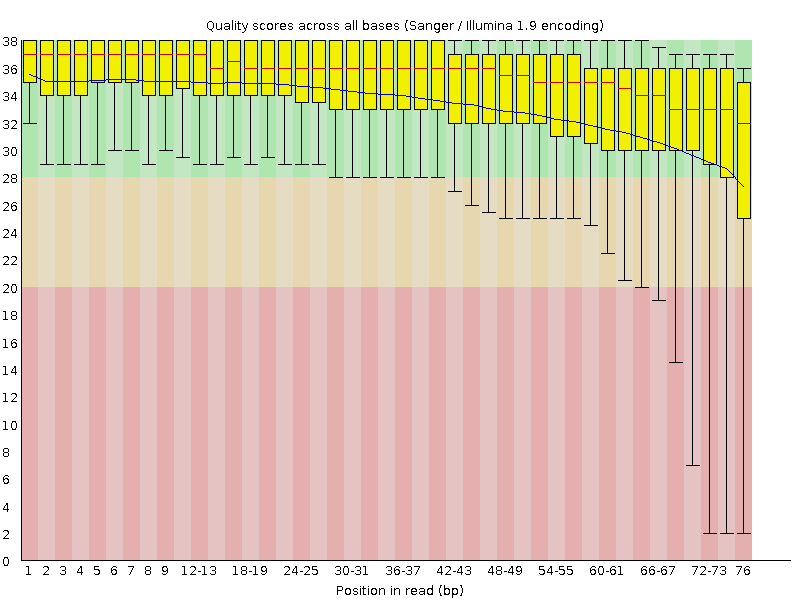

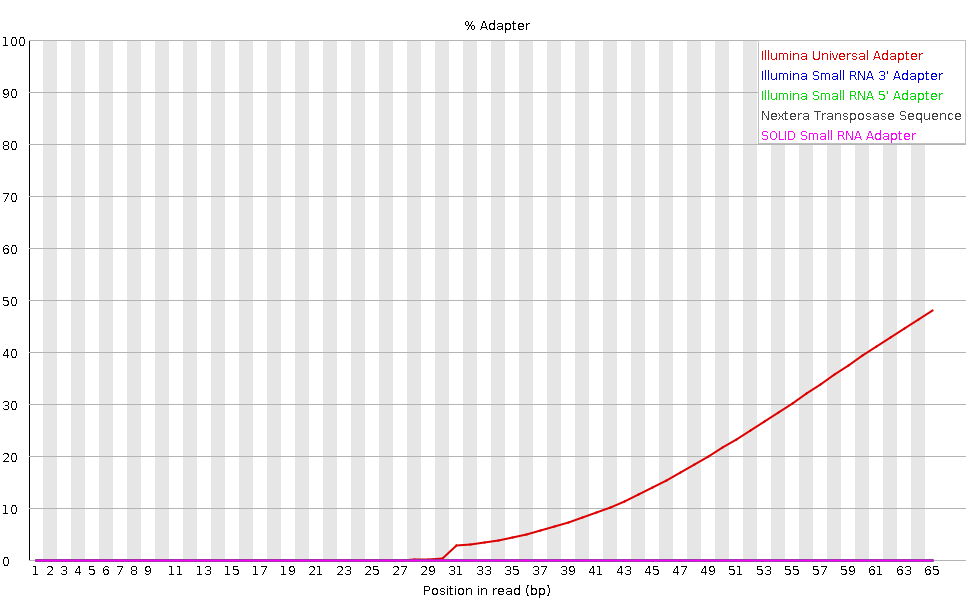

In [6]:
from IPython.display import Image, display
for d in ['SRR384977_1M_fastqc', 'SRR384980_1M_fastqc']:
    print('\n===', d)
    display(Image(f'{d}/Images/per_base_quality.png'))
    display(Image(f'{d}/Images/adapter_content.png'))

## Kendin dene

Önce iki dosyanın damga tablolarını karşılaştırın: hangi modüller farklı? Sonra raporun öbür grafiklerine de bakın (Images klasöründe hepsi var); özellikle "Overrepresented sequences" modülü ne diyor? Son görev: aynı analizi SRR384982 için yapın. Bulduklarınızı not edin; gizemi rehberde birlikte kapatacağız.